In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as kimage
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TF version:", tf.__version__)

TF version: 2.21.0


In [10]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

base_path = r"C:\Users\ganes\.cache\kagglehub\datasets\moazeldsokyx\dogs-vs-cats\versions\1\dataset"
train_dir = base_path + r"\train"
val_dir   = base_path + r"\validation"
test_dir  = base_path + r"\test"

print("Train exists:", os.path.exists(train_dir))
print("Val exists:",   os.path.exists(val_dir))

Train exists: True
Val exists: True


In [11]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

print("Classes:", train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Classes: {'cats': 0, 'dogs': 1}


In [12]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

model.save("dogs_vs_cats_model.keras")
print("Model saved!")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 350ms/step - accuracy: 0.6544 - loss: 0.6141 - val_accuracy: 0.7554 - val_loss: 0.5095 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 212s 338ms/step - accuracy: 0.7485 - loss: 0.5083 - val_accuracy: 0.7956 - val_loss: 0.4495 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 303ms/step - accuracy: 0.7852 - loss: 0.4518 - val_accuracy: 0.8016 - val_loss: 0.4282 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 341ms/step - accuracy: 0.8030 - loss: 0.4209 - val_accuracy: 0.7974 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 322ms/step - accuracy: 0.8194 - loss: 0.3919 - val_accuracy: 0.8340 - val_loss: 0.3773 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 314ms/step - accuracy: 0.8359 - loss: 0.3671 - val_accuracy: 0.8530 - val_loss: 0.3390 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 282ms/step - accura

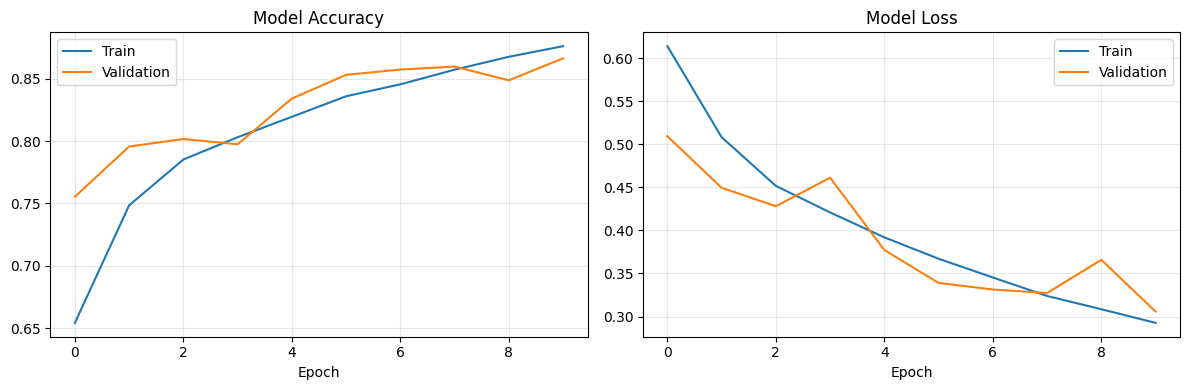

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"],     label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history["loss"],     label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step
              precision    recall  f1-score   support

         cat       0.49      0.48      0.49      2500
         dog       0.50      0.51      0.50      2500

    accuracy                           0.49      5000
   macro avg       0.49      0.49      0.49      5000
weighted avg       0.49      0.49      0.49      5000



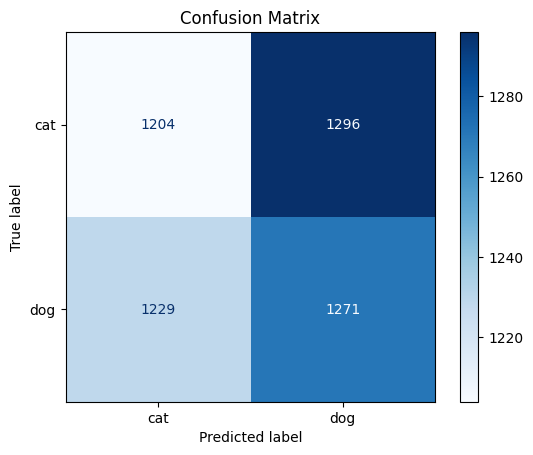

In [16]:
val_data.reset()

y_pred = (model.predict(val_data) > 0.5).astype(int).flatten()
y_true = val_data.classes

min_len = min(len(y_true), len(y_pred))
y_true, y_pred = y_true[:min_len], y_pred[:min_len]

print(classification_report(y_true, y_pred, target_names=["cat", "dog"], zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Model saved as dogs_vs_cats_model.h5
Model loaded successfully!
Total images found: 37461
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


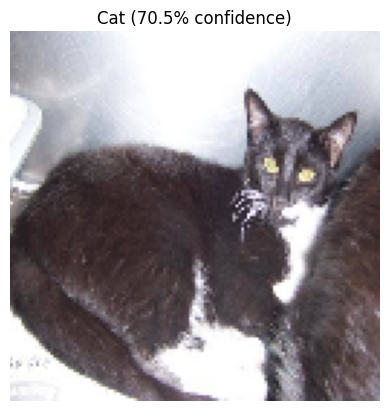

Prediction: Cat | Confidence: 0.7050


In [8]:
import os, random, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

IMG_SIZE  = (128, 128)
base_path = r"C:\Users\ganes\.cache\kagglehub\datasets\moazeldsokyx\dogs-vs-cats\versions\1\dataset"

# ── Save in h5 format (version-safe) ──────────────────────────
model.save("dogs_vs_cats_model.h5")
print("Model saved as dogs_vs_cats_model.h5")

# ── Reload it immediately to verify ───────────────────────────
from tensorflow.keras.models import load_model
model = load_model("dogs_vs_cats_model.h5", compile=False)
print("Model loaded successfully!")

# ── Predict on a random image ──────────────────────────────────
def predict_image(img_path):
    img  = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr  = kimage.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    prob = model.predict(arr)[0][0]
    label = "Dog" if prob > 0.5 else "Cat"
    conf  = prob if prob > 0.5 else 1 - prob
    plt.imshow(img)
    plt.title(f"{label} ({conf:.1%} confidence)")
    plt.axis("off")
    plt.show()
    print(f"Prediction: {label} | Confidence: {conf:.4f}")

images = []
for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            images.append(os.path.join(root, f))

print(f"Total images found: {len(images)}")
predict_image(random.choice(images))